In [1]:
import sys

import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import HTML

sys.path.append('../src')
import weather_utils
import plot_utils

In [2]:
fresh_pull = False
lat_range = (30.0, 50.0)
lon_range = (-120.0, -70.0)
start_date = '2025-11-01'
end_date = '2025-11-05'
variables = [
    '2m_temperature',
    'total_precipitation'
    ]
filename = (
    f"weather_data_lat_"
    f"{int(lat_range[0])}_{int(lat_range[1])}_"
    f"lon_{str(int(lon_range[0])).replace("-", "m")}_{str(int(lon_range[1])).replace("-", "m")}"
    f"_{start_date}_to_{end_date}"
)

if fresh_pull:
    weather_array = weather_utils.pull_era5_reanalysis(
        lat_range=(30.0, 50.0),
        lon_range=(-120.0, -70.0),
        start_date='2025-11-01',
        end_date='2025-11-05',
        variables=[
            '2m_temperature',
            'total_precipitation'
            ],
        output_file=f"../resources/{filename}.nc"
    )
else:
    weather_array = xr.open_dataset(f"../resources/{filename}_extracted.nc")

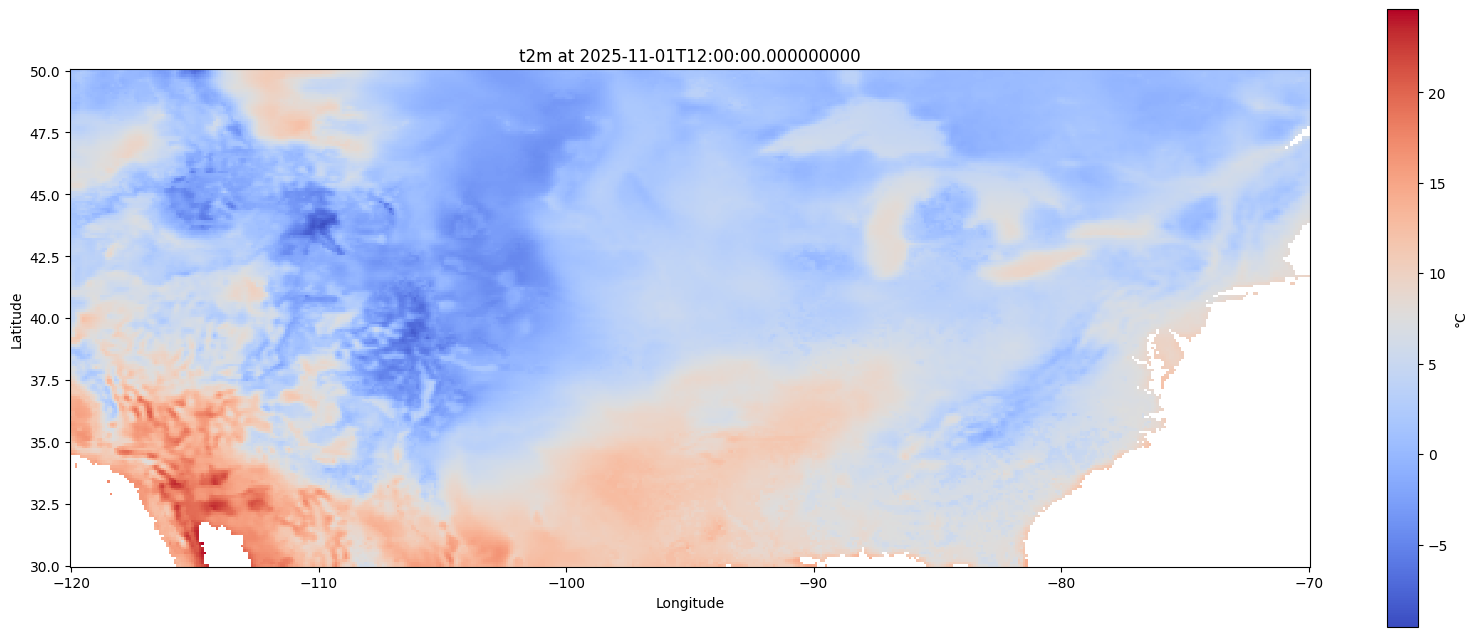

In [3]:
for time_idx in range(0, 1):
    plot_utils.plot_weather_data(
        weather_array=weather_array,
        weather_variable_name='t2m',
        time_idx=time_idx,
    )

In [4]:
animated_object = plot_utils.animate_weather_data(
    weather_array=weather_array,
    weather_variable_name="t2m",
    time_range=(0, 4),
    output_filepath=None,
)

HTML(animated_object.to_jshtml())